In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import threadpoolctl

# --- Neutralize the broken OpenBLAS introspection entirely ---
class _NoOpThreadpoolLimits:
    def __init__(self, *args, **kwargs):
        pass
    def __enter__(self):
        return self
    def __exit__(self, *exc):
        return False
    def unregister(self):
        pass
    def get_original_num_threads(self):
        return {}

def _noop_threadpool_info():
    return []

threadpoolctl.threadpool_limits = _NoOpThreadpoolLimits
threadpoolctl.threadpool_info = _noop_threadpool_info
# ---------------------------------------------------------------

import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=0, cluster_std=0.4)

In [3]:
df = pd.DataFrame(X,columns = ['F1', 'F2'])

In [4]:
df.head()

,F1,F2
0,2.285904,0.814344
1,0.618083,4.458548
2,2.434168,0.835660
3,0.330711,4.218691
4,0.556849,3.735780


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
inertia = []
k_range = range(1,11)

for k in k_range:
    k_means = KMeans(n_clusters = k)
    k_means.fit(X_scaled)
    inertia.append(k_means.inertia_)
inertia

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

[200.0,
 73.46172235345874,
 14.5552388045685,
 12.389508467959685,
 10.32662118157942,
 8.722015022074073,
 7.781947678054889,
 6.566171636585724,
 5.649659157224779,
 5.257928009959371]

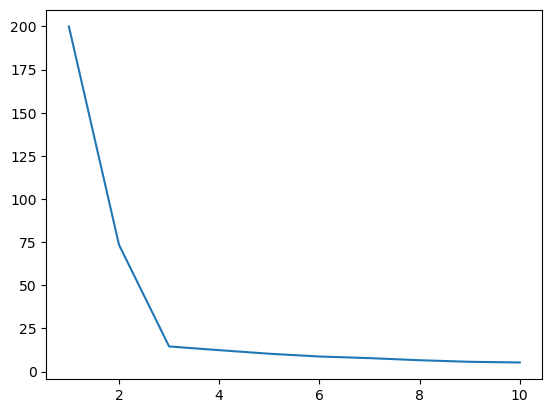

In [14]:
plt.plot(k_range,inertia)

In [16]:
k_means_final = KMeans(n_clusters=3)

In [18]:
clusters = k_means_final.fit_predict(X_scaled)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [20]:
df['cluster'] = clusters

In [22]:
df.head()

,F1,F2,cluster
0,2.285904,0.814344,1
1,0.618083,4.458548,2
2,2.434168,0.835660,1
3,0.330711,4.218691,2
4,0.556849,3.735780,2


<Axes: xlabel='F1', ylabel='F2'>

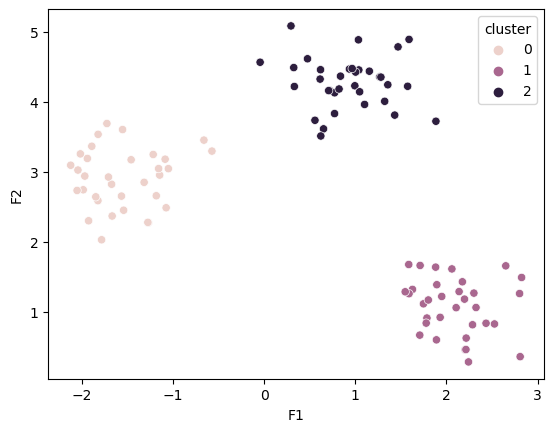

In [24]:
sns.scatterplot(x=df['F1'],y=df['F2'],hue=df['cluster'])

In [34]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, random_state=0)
df = pd.DataFrame(X,columns=['F1','F2'])

In [36]:
df.head()

,F1,F2
0,-0.096023,0.995379
1,1.672301,-0.240278
2,0.991790,0.127877
3,0.050944,0.184892
4,1.032052,-0.499486


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='F1', ylabel='F2'>

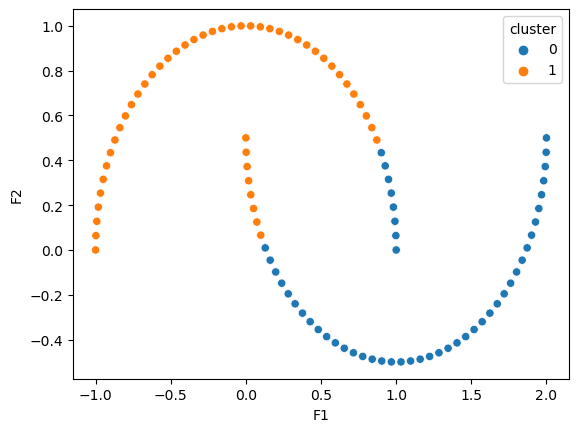

In [42]:
X_scaled = scaler.fit_transform(df)
k_means = KMeans(n_clusters=2)
clusters = k_means.fit_predict(X_scaled)
df['cluster'] = clusters
sns.scatterplot(x=df['F1'],y=df['F2'],hue=df['cluster'])

<Axes: xlabel='F1', ylabel='F2'>

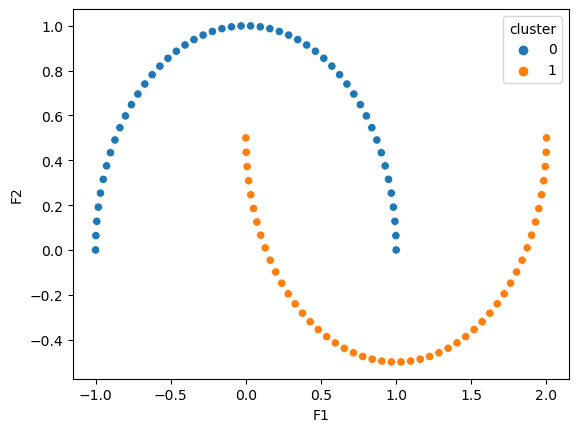

In [44]:
from sklearn.cluster import DBSCAN
db_scan = DBSCAN()
clusters = db_scan.fit_predict(X_scaled)
df['cluster'] = clusters
sns.scatterplot(x=df['F1'],y=df['F2'],hue=df['cluster'])